## I. Camera Geometric Calibration 

This calibration is performed using pyfai library. It is used to generate the following file(s):
- a *.poni file that contains all required information for further data processing
- an optional mask file (*.edf) to mask undiserable pixels

Note that beam center is automatically recalibrated before image processing. Distance and camera roation angles are assumed constant.

**/!\ Remember to save mask (.edf) and .poni files from pyFAI-calibration tool.**

In [1]:
from epdfsuite.calibration import perform_geometric_calibration

datapath = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/300kV/GrandARM/SESSION_I/Aufilm/'
sample_diff_calib = datapath + "300kV_K3_40X_3743.dm4" # Au calibrant diffraction data
# path to Au cif file used for calibration
cif_file = "/home-local/ratel-ra/Documents/CIF_database/Au_fixed.cif"

perform_geometric_calibration(
    image_file=sample_diff_calib,
    cif_file = cif_file)

Loaded file: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/300kV/GrandARM/SESSION_I/Aufilm/300kV_K3_40X_3743.dm4
Sample information:
  binning: 1
  description: Gatan K3 IS direct electron detector
  image_height: 3456
  image_width: 3456
  pixel_size: 5
  camera_type: K3 IS
  camera_title: 300kV_K3_40X_3743
  wavelength: 0.019687489006848795
  exposure_time: 119.96774699919368
EXPERIMENT SETTINGS TO INPUT IN PYFAI-CALIB2:
Camera description=Gatan K3 IS direct electron detector
pixel_size_x=5X5
image dimension=3456X3456
Electron wavelength=0.019687489006848795 Å
Launching pyFAI-calib2


## II. Camera Modulation Transfer Function (MTF) 

The can be computed using diffraction data acquired on amorhous C grid sample.
It can be determined using the function estimate_amorphous_carbon available in epdfsuite.utilities


In [2]:
%matplotlib widget
from epdfsuite.utilities import estimate_mtf_amorphous_carbon
from epdfsuite import SAEDProcessor


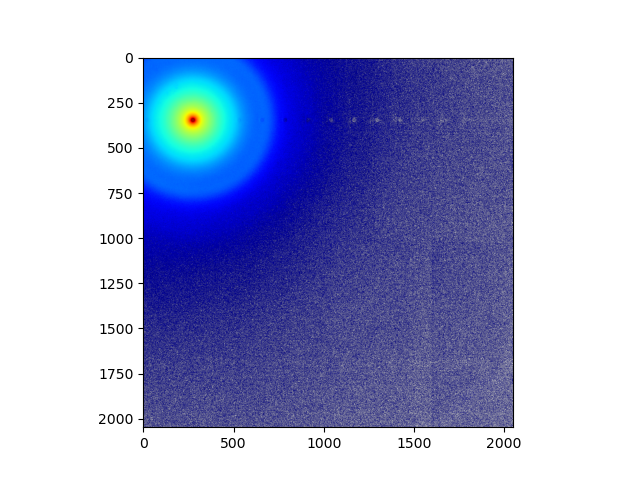

In [3]:

path = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_II/'
dataC = path + 'ref/500X_OneView_200kV_1412_Cfilm.dm4'
ponifile = path + 'calib_OneView_2k.poni'


processor = SAEDProcessor(dataC, ponifile)
processor.plot(cmap='jet')

In [4]:
processor.initial_center=[275.5,347.8]

/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/recalibration.py:217: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = morphology.remove_small_objects(binary, min_size=min_size)
/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/recalibration.py:250: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous par

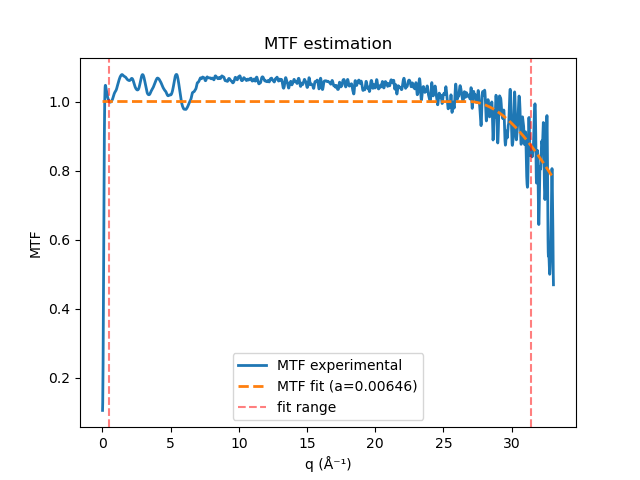

a=0.006463761657264217, q0=26.82538190313152


array([1.        , 1.        , 1.        , ..., 0.77887343, 0.77804299,
       0.77721167])

In [5]:
# define path to save MTF data
mtf_file = path + 'mtf_OneView_200kV_2k.mtf'

#Define qrange for MTF fitting
qmax_percent = 0.95

estimate_mtf_amorphous_carbon(processor, q_fit_max=qmax_percent, outputfile=mtf_file,plot=True)